# 沐曦 GPU 运行 uniGradICON 说明文档

[uniGradICON](https://github.com/uncbiag/uniGradICON) 是面向三维医学图像配准的基础模型，基于 [GradICON](https://github.com/uncbiag/ICON) 的梯度逆一致性约束训练，可为 CT、MRI 等三维医学图像估计稠密可变形映射。本 Notebook 使用 [Slicer Registration Library Case #1](https://www.slicer.org/wiki/Documentation:Nightly:Registration:RegistrationLibrary:RegLib_C01) 的脑肿瘤基线/随访 MRI 配对，在沐曦 GPU 上完成 moving 到 fixed 的可变形配准并展示结果。

[uniGradICON](https://github.com/uncbiag/uniGradICON) 由第三方以 Apache License 2.0 发布，我方未对其源代码作任何修改。您可通过上游项目页面查阅源代码、许可证全文、版权与归属声明及其他项目文档；本目录中的 `LICENSE` 为上游许可证全文。

本示例用于开源软件适配与工程验证，不用于诊断、治疗、患者管理、临床决策或监管提交。

## 1. 安装

### 1.1 沐曦容器

```bash
docker run -it --name test-unigradicon \
  --device=/dev/mxcd --device=/dev/dri --group-add video \
  --shm-size=8G --security-opt seccomp=unconfined \
  --ulimit memlock=-1 --ulimit stack=67108864 \
  -v /workspace:/workspace \
  cr.metax-tech.com/public-library/maca-pytorch:3.8.0.11-torch2.6-py310-ubuntu24.04-amd64 /bin/bash
```

`--device=/dev/mxcd --device=/dev/dri` 挂载沐曦 GPU，`--group-add video` 提供设备访问权限，`--shm-size=8G` 为三维图像和模型提供共享内存。

### 1.2 安装依赖并准备权重

```bash
python -m pip install unigradicon itk matplotlib

mkdir -p /workspace/unigradicon_demo/weights
wget https://github.com/uncbiag/uniGradICON/releases/download/unigradicon_weights/Step_2_final.trch \
  -O /workspace/unigradicon_demo/weights/Step_2_final.trch
```

## 2. 沐曦 GPU 运行效果展示

### 2.1 运行参数

以下参数是后续输入准备、模型推理、输出保存和可视化的统一入口。

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import contextlib
import io
import os
import time

import icon_registration
import itk
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import torch
from unigradicon import get_unigradicon, make_sim, maybe_cast, preprocess

if not torch.cuda.is_available():
    raise RuntimeError('未检测到沐曦 CUDA 兼容设备')

DEVICE = torch.device('cuda:0')
MODEL = 'unigradicon'
WORK_DIR = Path(os.environ.get('UNIGRADICON_WORK_DIR', '/workspace/unigradicon_demo'))
WEIGHTS = Path(os.environ.get(
    'UNIGRADICON_WEIGHTS', WORK_DIR / 'weights' / 'Step_2_final.trch'
))
DATA_DIR = WORK_DIR / 'data'
OUTPUT_DIR = WORK_DIR / 'outputs'
FIXED_PATH = DATA_DIR / 'RegLib_C01_2.nrrd'
MOVING_PATH = DATA_DIR / 'RegLib_C01_1.nrrd'
FIXED_MODALITY = 'mri'
MOVING_MODALITY = 'mri'
IO_ITERATIONS = 50
IO_SIM = 'lncc'

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

print('PyTorch:', torch.__version__)
print('GPU:', torch.cuda.get_device_name(0))
print('Model:', MODEL)
print('Weights:', WEIGHTS)
print('Fixed:', FIXED_PATH, '| modality:', FIXED_MODALITY)
print('Moving:', MOVING_PATH, '| modality:', MOVING_MODALITY)
print('Instance Optimization:', IO_ITERATIONS, '| similarity:', IO_SIM)
print('Output directory:', OUTPUT_DIR)

PyTorch: 2.6.0+metax3.8.2.2
GPU: MetaX C500
Model: unigradicon
Weights: /workspace/unigradicon_demo/weights/Step_2_final.trch
Fixed: /workspace/unigradicon_demo/data/RegLib_C01_2.nrrd | modality: mri
Moving: /workspace/unigradicon_demo/data/RegLib_C01_1.nrrd | modality: mri
Instance Optimization: 50 | similarity: lncc
Output directory: /workspace/unigradicon_demo/outputs


### 2.2 准备真实临床 MRI 图像

RegLib C01 是同一受试者脑肿瘤基线与随访 MRI 配对。fixed 使用基线图像，moving 使用随访图像；若工作目录中尚无文件，下面的代码会从 uniGradICON 官方 README 引用的公共镜像下载。

In [2]:
DATA_URLS = {
    FIXED_PATH: 'https://www.hgreer.com/assets/slicer_mirror/RegLib_C01_2.nrrd',
    MOVING_PATH: 'https://www.hgreer.com/assets/slicer_mirror/RegLib_C01_1.nrrd',
}
for path, url in DATA_URLS.items():
    if not path.exists():
        urlretrieve(url, path)

if not WEIGHTS.is_file():
    raise FileNotFoundError(f'未找到模型权重：{WEIGHTS}')

print('Data source: Slicer Registration Library Case #1 / uniGradICON public mirror')
print('Fixed bytes:', FIXED_PATH.stat().st_size)
print('Moving bytes:', MOVING_PATH.stat().st_size)

Data source: Slicer Registration Library Case #1 / uniGradICON public mirror
Fixed bytes: 6132840
Moving bytes: 5069225


Fixed shape (z, y, x): (130, 256, 256)
Fixed spacing (x, y, z): (0.9375, 0.9375, 1.2)
Moving shape (z, y, x): (112, 256, 256)
Moving spacing (x, y, z): (0.9375, 0.9375, 1.4)


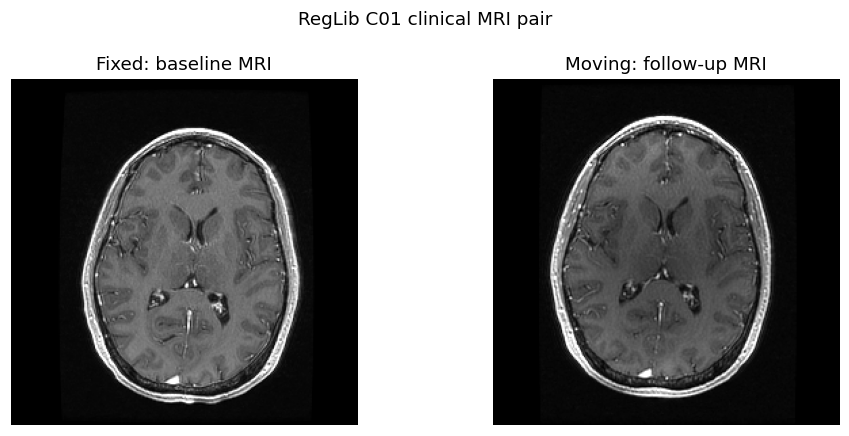

In [3]:
fixed = itk.imread(str(FIXED_PATH))
moving = itk.imread(str(MOVING_PATH))
fixed_array = np.asarray(itk.array_view_from_image(fixed))
moving_array = np.asarray(itk.array_view_from_image(moving))

print('Fixed shape (z, y, x):', fixed_array.shape)
print('Fixed spacing (x, y, z):', tuple(round(x, 4) for x in fixed.GetSpacing()))
print('Moving shape (z, y, x):', moving_array.shape)
print('Moving spacing (x, y, z):', tuple(round(x, 4) for x in moving.GetSpacing()))

def show_gray(axis, image, title, limits=None):
    low, high = limits or np.percentile(image, (1, 99))
    axis.imshow(image, cmap='gray', vmin=low, vmax=high)
    axis.set_title(title)
    axis.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
show_gray(axes[0], fixed_array[fixed_array.shape[0] // 2], 'Fixed: baseline MRI')
show_gray(axes[1], moving_array[moving_array.shape[0] // 2], 'Moving: follow-up MRI')
fig.suptitle('RegLib C01 clinical MRI pair')
plt.tight_layout()
plt.show()

### 2.3 运行三维可变形配准

本单元格直接调用 uniGradICON 上游 Python API。计时范围包含 50 次 Instance Optimization 和最终形变计算，不包含模型加载、文件读取与结果写盘。

In [4]:
net = get_unigradicon(
    loss_fn=make_sim(IO_SIM),
    weights_location=str(WEIGHTS),
)
moving_input = preprocess(moving, MOVING_MODALITY)
fixed_input = preprocess(fixed, FIXED_MODALITY)

torch.cuda.synchronize()
started = time.perf_counter()
with contextlib.redirect_stdout(io.StringIO()):
    phi_ab, _ = icon_registration.itk_wrapper.register_pair(
        net, moving_input, fixed_input, finetune_steps=IO_ITERATIONS
    )
torch.cuda.synchronize()
inference_seconds = time.perf_counter() - started

transform_path = OUTPUT_DIR / 'transform.hdf5'
warped_path = OUTPUT_DIR / 'warped_moving.nrrd'
vectorfield_path = OUTPUT_DIR / 'phi_AB_vectorfield.npz'
itk.transformwrite([phi_ab], str(transform_path))

moving_for_warp, cast_back = maybe_cast(moving)
warped = itk.resample_image_filter(
    moving_for_warp,
    transform=phi_ab,
    interpolator=itk.LinearInterpolateImageFunction.New(moving_for_warp),
    use_reference_image=True,
    reference_image=fixed,
)
warped = cast_back(warped)
itk.imwrite(warped, str(warped_path))

field = net.phi_AB_vectorfield.detach().float().cpu().numpy()[0]
np.savez_compressed(
    vectorfield_path,
    phi_AB_vectorfield=field,
    coordinate_system=np.asarray('normalized-index-coordinates-[0,1]'),
)

print('Inference completed on:', torch.cuda.get_device_name(0))
print('Inference time (s):', round(inference_seconds, 3))
print('Network field shape (component, i, j, k):', field.shape)
print('Transform:', transform_path)
print('Warped moving:', warped_path)
print('Normalized coordinate field:', vectorfield_path)

Inference completed on: MetaX C500
Inference time (s): 85.437
Network field shape (component, i, j, k): (3, 175, 175, 175)
Transform: /workspace/unigradicon_demo/outputs/transform.hdf5
Warped moving: /workspace/unigradicon_demo/outputs/warped_moving.nrrd
Normalized coordinate field: /workspace/unigradicon_demo/outputs/phi_AB_vectorfield.npz


### 2.4 配准结果

为了在同一 fixed 网格上比较，先分别使用恒等变换和模型变换重采样预处理后的 moving。归一化 MSE 只用于本例的工程对齐检查，不代表临床配准准确率。

Warped shape (z, y, x): (130, 256, 256)
Fixed geometry preserved: True
Normalized MSE before: 0.044639
Normalized MSE after: 0.005384


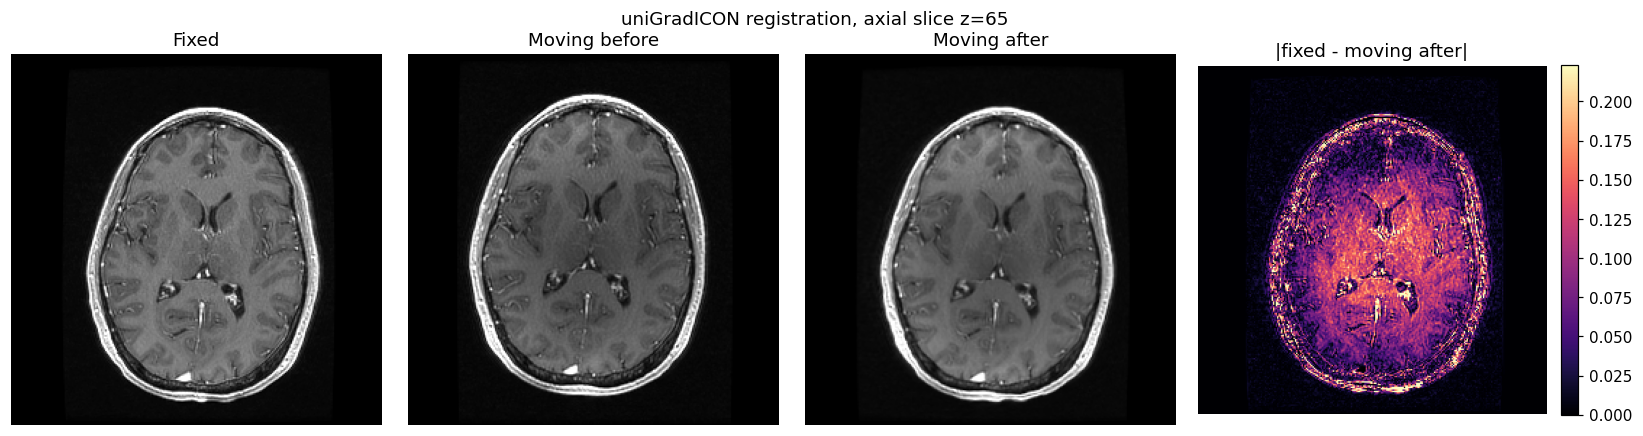

In [5]:
identity = itk.IdentityTransform[itk.D, 3].New()
moving_interpolator = itk.LinearInterpolateImageFunction.New(moving_input)
moving_before = itk.resample_image_filter(
    moving_input,
    transform=identity,
    interpolator=moving_interpolator,
    use_reference_image=True,
    reference_image=fixed_input,
)
moving_after = itk.resample_image_filter(
    moving_input,
    transform=phi_ab,
    interpolator=moving_interpolator,
    use_reference_image=True,
    reference_image=fixed_input,
)

fixed_norm = np.asarray(itk.array_view_from_image(fixed_input))
before_norm = np.asarray(itk.array_view_from_image(moving_before))
after_norm = np.asarray(itk.array_view_from_image(moving_after))
warped_array = np.asarray(itk.array_view_from_image(warped))
mse_before = float(np.mean((fixed_norm - before_norm) ** 2))
mse_after = float(np.mean((fixed_norm - after_norm) ** 2))
same_geometry = (
    warped_array.shape == fixed_array.shape
    and np.allclose(warped.GetSpacing(), fixed.GetSpacing())
    and np.allclose(warped.GetOrigin(), fixed.GetOrigin())
    and np.allclose(
        itk.array_from_matrix(warped.GetDirection()),
        itk.array_from_matrix(fixed.GetDirection()),
    )
)

slice_id = fixed_norm.shape[0] // 2
difference = np.abs(fixed_norm - after_norm)
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
show_gray(axes[0], fixed_norm[slice_id], 'Fixed')
show_gray(axes[1], before_norm[slice_id], 'Moving before')
show_gray(axes[2], after_norm[slice_id], 'Moving after')
limit = max(float(np.percentile(difference[slice_id], 99)), 1e-6)
image = axes[3].imshow(difference[slice_id], cmap='magma', vmin=0, vmax=limit)
axes[3].set_title('|fixed - moving after|')
axes[3].axis('off')
fig.colorbar(image, ax=axes[3], fraction=0.046, pad=0.04)
fig.suptitle(f'uniGradICON registration, axial slice z={slice_id}')
plt.tight_layout()
plt.show()

print('Warped shape (z, y, x):', warped_array.shape)
print('Fixed geometry preserved:', same_geometry)
print('Normalized MSE before:', round(mse_before, 6))
print('Normalized MSE after:', round(mse_after, 6))

### 2.5 Jacobian 工程检查

Jacobian determinant 描述变换的局部体积变化：接近 1 表示局部体积变化较小，非正值表示局部折叠。该结果是几何工程检查，不是临床质量判定。

Jacobian: /workspace/unigradicon_demo/outputs/jacobian.nrrd
Shape: (130, 256, 256)
All finite: True
1st / 50th / 99th percentile: (0.5784, 1.0084, 1.5502)
Non-positive voxel fraction: 0.0


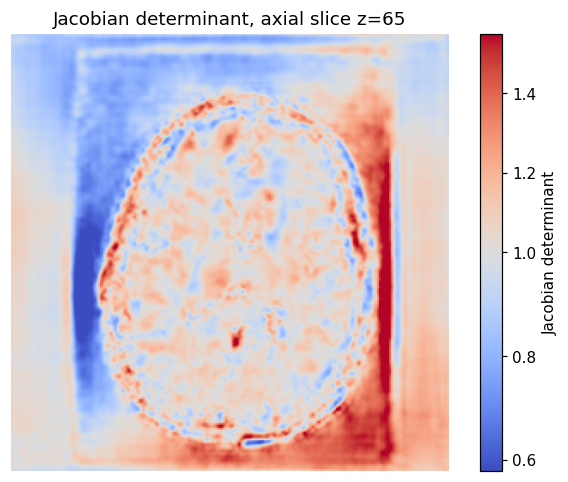

In [6]:
saved_transform = itk.transformread(str(transform_path))[0]
displacement = itk.transform_to_displacement_field_filter(
    saved_transform, reference_image=fixed, use_reference_image=True
)
jacobian = itk.displacement_field_jacobian_determinant_filter(displacement)
jacobian_path = OUTPUT_DIR / 'jacobian.nrrd'
itk.imwrite(jacobian, str(jacobian_path))
jacobian_array = np.asarray(itk.array_view_from_image(jacobian))
finite = np.isfinite(jacobian_array)
q01, q50, q99 = np.quantile(jacobian_array[finite], (0.01, 0.50, 0.99))
fold_fraction = float(np.mean(jacobian_array <= 0))

low = min(float(q01), 0.99)
high = max(float(q99), 1.01)
fig, ax = plt.subplots(figsize=(6, 4.5))
image = ax.imshow(
    jacobian_array[slice_id],
    cmap='coolwarm',
    norm=TwoSlopeNorm(vmin=low, vcenter=1.0, vmax=high),
)
ax.set_title(f'Jacobian determinant, axial slice z={slice_id}')
ax.axis('off')
fig.colorbar(image, ax=ax, label='Jacobian determinant')
plt.tight_layout()
plt.show()

print('Jacobian:', jacobian_path)
print('Shape:', jacobian_array.shape)
print('All finite:', bool(finite.all()))
print('1st / 50th / 99th percentile:', tuple(round(float(x), 4) for x in (q01, q50, q99)))
print('Non-positive voxel fraction:', round(fold_fraction, 8))

---
本文档仅提供相关软件的配置与使用说明，不包含亦不分发前述软件的源代码或目标代码，且不涉及对其源代码的任何修改。您按照本文档配置、部署或使用相关软件时，应遵守适用许可证规定的条款及条件。相关软件的源代码、许可证全文、版权与归属声明及其他项目文档，请以其官方网站或原始发布页面为准。 

Copyright (c) 2026 MetaX Integrated Circuits (Shanghai) Co., Ltd. All rights reserved.